In [133]:
import sys
import os
import pandas as pd
from pathlib import Path

In [134]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

from src.extract import extract_batch


In [135]:
df_energy_headlines = pd.read_csv('../data/processed/energy_headlines.csv')
df_energy_headlines.head()


,webTitle,webPublicationDate,webUrl,sectionName
0,Can bears swing upside down and what colour is electricity? The kids’ quiz,2025-08-02 06:00:04+00:00,https://www.theguardian.com/lifeandstyle/2025/aug/02/can-bears-swing-upside-down-and-what-colour-is-electricity-the-kids-quiz,Life and style
1,‘He was angry’: India admit wind-up strategy to disrupt Joe Root’s batting,2025-08-01 20:27:18+00:00,https://www.theguardian.com/sport/2025/aug/01/he-was-angry-india-admit-wind-up-strategy-to-disrupt-roots-batting,Sport
2,Starmer defends investment in wind turbines after Trump wrongly claims it is ‘most expensive form of energy’ – as it happened,2025-07-28 17:52:00+00:00,https://www.theguardian.com/politics/live/2025/jul/28/starmer-trump-meeting-gaza-trade-palestine-latest-live-uk-politics-updates-news,Politics
3,Neo-Nazi leader sentenced to 20 years for plot to attack Maryland’s power grid,2025-08-08 05:01:20+00:00,https://www.theguardian.com/us-news/2025/aug/08/neo-nazi-leader-sentenced-to-20-years-for-plot-to-attack-marylands-power-grid,US news
4,Elon Musk’s Tesla applies to supply electricity to households in Great Britain,2025-08-10 15:35:25+00:00,https://www.theguardian.com/technology/2025/aug/10/elon-musk-tesla-applies-to-supply-electricity-to-households-in-great-britain,Technology


In [136]:
extract_batch(df_energy_headlines, Path(".." )/ "data" / "processed" / "extractions.json")


{'https://www.theguardian.com/money/2026/mar/18/energy-bills-uk-government-urged-to-launch-social-tariff-to-help-vulnerable-households': {'event_type': 'none',
  'region': 'UK'},
 'https://www.theguardian.com/environment/2026/may/12/datacentres-australia-wind-solar-energy-investment': {'event_type': 'none',
  'region': 'other'},
 'https://www.theguardian.com/thefilter-us/2026/jan/27/extreme-cold-warm-winter-clothing': {'event_type': 'none',
  'region': 'UK'},
 'https://www.theguardian.com/money/2025/aug/27/higher-energy-bills-price-cap-rises': {'event_type': 'none',
  'region': 'UK'},
 'https://www.theguardian.com/environment/2026/apr/22/eu-plans-cut-electricity-taxes-shield-households-iran-war-energy-crisis': {'event_type': 'none',
  'region': 'Europe'},
 'https://www.theguardian.com/environment/2026/jan/14/solar-grazing-triple-win-sheep-farmers-renewables-energy-companies': {'event_type': 'none',
  'region': 'other'},
 'https://www.theguardian.com/money/2025/sep/23/energy-bills-milli

In [137]:
#Load the weather focused pull (752 headlines from ingest_weather.py, saved as its own csv)
#Only 40 of these were hand labelled (gold_enriched); the rest get LLM labels here
df_weather_headlines = pd.read_csv('../data/processed/weather_headlines.csv')
print(df_weather_headlines.shape)
df_weather_headlines.head()

(752, 4)


,webTitle,webPublicationDate,webUrl,sectionName
0,Nordic countries hit by ‘truly unprecedented’ heatwave,2025-08-02 09:00:07+00:00,https://www.theguardian.com/environment/2025/aug/02/nordic-countries-hit-by-truly-unprecedented-heatwave,Environment
1,Beware the blizzard of lies: US advice on how to handle Farage’s Trump tactics,2025-07-26 08:47:07+00:00,https://www.theguardian.com/politics/2025/jul/26/beware-the-blizzard-of-lies-us-advice-on-how-to-handle-farages-trump-tactics,Politics
2,Weather tracker: Cooldown in sight for south-east Europe after scorching heatwave,2025-07-28 09:37:45+00:00,https://www.theguardian.com/environment/2025/jul/28/weather-tracker-cooldown-in-sight-for-south-east-europe-after-scorching-heatwave,Environment
3,Eastern US swelters from heatwave as high temperatures affect half of country,2025-07-28 20:46:01+00:00,https://www.theguardian.com/us-news/2025/jul/28/us-weather-heatwave-temperatures-east,Environment
4,"UK has not hit ‘peak Greggs’, says CEO, as sales slow in heatwave",2025-07-29 12:05:53+00:00,https://www.theguardian.com/business/2025/jul/29/uk-peak-greggs-ceo-sales-bakery-chain-profit,Business


In [138]:
#Label the weather pool with the LLM. Cache skips anything already extracted,
#so the 40 gold_enriched rows and any overlap with the energy pull cost nothing
extract_batch(df_weather_headlines, Path("..") / "data" / "processed" / "extractions.json")

{'https://www.theguardian.com/money/2026/mar/18/energy-bills-uk-government-urged-to-launch-social-tariff-to-help-vulnerable-households': {'event_type': 'none',
  'region': 'UK'},
 'https://www.theguardian.com/environment/2026/may/12/datacentres-australia-wind-solar-energy-investment': {'event_type': 'none',
  'region': 'other'},
 'https://www.theguardian.com/thefilter-us/2026/jan/27/extreme-cold-warm-winter-clothing': {'event_type': 'none',
  'region': 'UK'},
 'https://www.theguardian.com/money/2025/aug/27/higher-energy-bills-price-cap-rises': {'event_type': 'none',
  'region': 'UK'},
 'https://www.theguardian.com/environment/2026/apr/22/eu-plans-cut-electricity-taxes-shield-households-iran-war-energy-crisis': {'event_type': 'none',
  'region': 'Europe'},
 'https://www.theguardian.com/environment/2026/jan/14/solar-grazing-triple-win-sheep-farmers-renewables-energy-companies': {'event_type': 'none',
  'region': 'other'},
 'https://www.theguardian.com/money/2025/sep/23/energy-bills-milli

In [139]:
#Attach LLM predictions to every headline from both pulls
#The two queries overlapped slightly, so dedupe on webUrl first
df_all = pd.concat([df_energy_headlines, df_weather_headlines], ignore_index=True)
df_all = df_all.drop_duplicates(subset=['webUrl'])

df_extractions = pd.read_json('../data/processed/extractions.json').T.reset_index().rename(columns={'index': 'webUrl'})

#Left join on df_all because every headline must survive with a prediction attached
df_master = df_all.merge(df_extractions, on='webUrl', how='left')
assert df_master['event_type'].notna().all(), "some headlines have no prediction"
df_master['label_source'] = 'predicted'
print(df_master.shape)

(1022, 7)


In [140]:
#Where hand labels exist (the 140 gold rows), prefer them over predictions
gold = pd.concat([pd.read_csv('../data/labeled/gold.csv'),
                  pd.read_csv('../data/labeled/gold_enriched.csv')], ignore_index=True)
gold_map = gold.set_index('webUrl')[['event_type', 'region']]

mask = df_master['webUrl'].isin(gold_map.index)
df_master.loc[mask, 'event_type'] = df_master.loc[mask, 'webUrl'].map(gold_map['event_type'])
df_master.loc[mask, 'region'] = df_master.loc[mask, 'webUrl'].map(gold_map['region'])
df_master.loc[mask, 'label_source'] = 'gold'

print(df_master['label_source'].value_counts())

label_source
predicted    882
gold         140
Name: count, dtype: int64


In [141]:
#Keep only rows that are usable events for the price join:
#an actual weather event, in a market we have prices for

#Europe-labelled events are excluded: they cannot be attributed to a single price market
#without asserting geography the headline does not state
#(example: "heatwave moves east" may never have touched Spain)

df_events = df_master.loc[(df_master['event_type'] != 'none') &
                          (df_master['region'].isin(['UK', 'Germany', 'France', 'Spain', 'Netherlands']))].copy()
print(f"{len(df_events)} event headlines")
df_events[['webTitle', 'event_type', 'region', 'label_source']].head(15)

160 event headlines


,webTitle,event_type,region,label_source
110,Amsterdam airport cancels at least 800 flights because of snow and wind,cold,Netherlands,gold
278,I am used to hot days now. But the warm wind has really panicked me | Adrian Chiles,heatwave,UK,predicted
283,"UK has not hit ‘peak Greggs’, says CEO, as sales slow in heatwave",heatwave,UK,predicted
286,Glorious Goodwood: Whirl dances through storm after messy flag start,storm,UK,predicted
289,Storm Floris to hit UK on Monday with unseasonably strong winds forecast,storm,UK,predicted
296,Storm Floris: 90mph gusts hit train services – live updates,storm,UK,predicted
298,Storm Floris prompts danger to life warning for parts of UK,storm,UK,predicted
300,"Storm Floris brings winds of 100mph, travel disruption and power cuts to UK",storm,UK,predicted
304,Can the Millbrook Wool Luxury 4000 mattress really keep you cool at night? I slept on it in a heatwave to find out,heatwave,UK,predicted
312,Thousands evacuated in Spain as deadly heatwave fans Mediterranean wildfires,heatwave,Spain,predicted


In [142]:
#Multiple headlines about the same storm within a couple of days are one event, not several
#Within each (region, event_type) group, a headline starts a new event only if it comes
#more than 2 days after the previous headline; chained daily coverage stays one event
df_events['date'] = pd.to_datetime(df_events['webPublicationDate'], utc=True).dt.date
df_events = df_events.sort_values(['region', 'event_type', 'date'])

clustered = []
for (region, etype), g in df_events.groupby(['region', 'event_type']):
    last_date = None
    for _, row in g.iterrows():
        if last_date is None or (row['date'] - last_date).days > 2:
            clustered.append(row)
        last_date = row['date']

events_final = pd.DataFrame(clustered)[['date', 'region', 'event_type', 'webTitle', 'label_source']]
print(f"{len(df_events)} event headlines -> {len(events_final)} distinct events")
events_final.sort_values('date').reset_index(drop=True)

160 event headlines -> 63 distinct events


,date,region,event_type,webTitle,label_source
0,2025-07-29,UK,heatwave,"UK has not hit ‘peak Greggs’, says CEO, as sales slow in heatwave",predicted
1,2025-07-31,UK,storm,Glorious Goodwood: Whirl dances through storm after messy flag start,predicted
2,2025-08-03,UK,heatwave,Can the Millbrook Wool Luxury 4000 mattress really keep you cool at night? I slept on it in a heatwave to find out,predicted
3,2025-08-12,Spain,heatwave,Thousands evacuated in Spain as deadly heatwave fans Mediterranean wildfires,predicted
4,2025-08-21,UK,drought,"Drought bringing autumn harvest two weeks early, Waitrose says",predicted
...,...,...,...,...,...
58,2026-07-12,Germany,heatwave,"Germany records nearly 100 drowning deaths, many of them young men, in June heatwave",predicted
59,2026-07-13,UK,heatwave,"UK in ‘firewave’ as extreme heat provides ideal conditions for wildfires, experts warn",predicted
60,2026-07-20,UK,drought,Country diary: Beaver-style flood defences take root amid a hosepipe ban | Kate Blincoe,predicted
61,2026-07-22,France,heatwave,"France records more than 5,700 excess deaths during June heatwave",predicted


In [143]:
pd.set_option('display.max_colwidth', None)
for i, row in events_final.sort_values('date').iterrows():
    print(f"{i:3}  {row['date']}  {row['region']:12} {row['event_type']:9} [{row['label_source']}]  {row['webTitle']}")

283  2025-07-29  UK           heatwave  [predicted]  UK has not hit ‘peak Greggs’, says CEO, as sales slow in heatwave
286  2025-07-31  UK           storm     [predicted]  Glorious Goodwood: Whirl dances through storm after messy flag start
304  2025-08-03  UK           heatwave  [predicted]  Can the Millbrook Wool Luxury 4000 mattress really keep you cool at night? I slept on it in a heatwave to find out
312  2025-08-12  Spain        heatwave  [predicted]  Thousands evacuated in Spain as deadly heatwave fans Mediterranean wildfires
326  2025-08-21  UK           drought   [predicted]  Drought bringing autumn harvest two weeks early, Waitrose says
330  2025-08-21  UK           storm     [predicted]  Hurricane Erin’s tail may bring wet and windy end to UK summer
341  2025-08-26  UK           drought   [predicted]  ‘It’s a disaster’: drought measure to suck water from River Wharfe met with anger
353  2025-09-05  UK           flood     [predicted]  Son who found mother’s body after Storm B

In [144]:
drop_idx = [286, 304, 341, 353, 359, 360, 405, 453, 461, 500, 501, 512, 547, 567,
            572, 588, 597, 621, 669, 673, 684, 699, 700, 717, 775, 799, 849, 901,
            912, 951, 955, 997, 1006, 1012]
events_final = events_final.drop(index=drop_idx)
events_final.loc[632, 'event_type'] = 'storm'   #named storm tie-break (Storm Chandra)
print(len(events_final))
events_final.sort_values('date')

29


,date,region,event_type,webTitle,label_source
283,2025-07-29,UK,heatwave,"UK has not hit ‘peak Greggs’, says CEO, as sales slow in heatwave",predicted
312,2025-08-12,Spain,heatwave,Thousands evacuated in Spain as deadly heatwave fans Mediterranean wildfires,predicted
330,2025-08-21,UK,storm,Hurricane Erin’s tail may bring wet and windy end to UK summer,predicted
326,2025-08-21,UK,drought,"Drought bringing autumn harvest two weeks early, Waitrose says",predicted
387,2025-10-01,UK,storm,Weather warnings as Storm Amy to batter UK this weekend,predicted
413,2025-10-24,France,storm,Weather tracker: Tornadoes and Storm Benjamin lash northern France,predicted
470,2025-11-14,UK,storm,Storm Claudia: torrential rain expected in parts of England and Wales,predicted
504,2025-12-01,UK,flood,Extensive flooding possible in Wales as Met Office issues amber weather warning,predicted
525,2025-12-09,UK,storm,Storm Bram batters Britain and Ireland with strong winds and heavy rain,gold
537,2025-12-19,Spain,storm,Weather tracker: Early snowfall in New York and a storm ruins Christmas lights in Spain,predicted


In [145]:
prices = pd.read_csv('../data/processed/prices.csv', parse_dates=['date'])
prices['date'] = prices['date'].dt.date
#Set regione and date for fast lookup of prices
price_lookup = prices.set_index(['region', 'date'])['price']



In [146]:
#Event study: did prices behave abnormally around weather event headlines?
#Baseline = mean price over the 7 days BEFORE the event (days -7 to -1), each event
#compared against its own quiet week so winter events are judged by winter norms.
#Window = days -3 to +5 around the event. The days before the event should show
#abnormal ~0 (sanity check); any real effect appears at day 0 and after.
#abnormal_pct = (price - baseline) / baseline * 100

from datetime import timedelta
import statistics

def event_study(events_df, price_lookup, baseline_days=7, window=range(-3, 6)):
    results = []
    skipped = 0

    for _, ev in events_df.iterrows():
        region, edate = ev['region'], ev['date']

        #1. collect baseline prices: for offset 1..baseline_days,
        #   look up 
        #   keep only the ones that are not None
        baseline_results = []
        for offset in range(1,baseline_days+1):
            baseline_price = price_lookup.get((region,edate - timedelta(days = offset )))
            if baseline_price is not None and pd.notna(baseline_price):
                baseline_results.append(baseline_price)

        #2. if fewer than 5 baseline prices survived: skipped += 1, continue
        #   else baseline = their mean
        if len(baseline_results) < 5:
            skipped +=1
        else: 
            baseline_avg = statistics.mean(baseline_results)

        #3. 
            for d in window:
                price = price_lookup.get((region, edate + timedelta(d)))

                if price is not None and pd.notna(price):
                    abnormal_pct = (price - baseline_avg)/baseline_avg *100
                    results.append(
                        {
                            'webTitle': ev['webTitle'],
                            'region': region,
                            'event_type': ev['event_type'],
                            'rel_day' : d,
                            'abnormal_pct': abnormal_pct

                    })

               
    print(f"skipped {skipped} events with thin baselines")
    return pd.DataFrame(results)





In [147]:
#Run the function on our dataset to see how weather events 
# affect European energy prices
df_results = event_study(events_final, price_lookup, baseline_days=7, window=range(-3, 6))

df_results.head()



skipped 1 events with thin baselines


,webTitle,region,event_type,rel_day,abnormal_pct
0,France issues red flood alerts after ‘exceptional’ rainfall,France,flood,-3,21.532285
1,France issues red flood alerts after ‘exceptional’ rainfall,France,flood,-2,-57.034718
2,France issues red flood alerts after ‘exceptional’ rainfall,France,flood,-1,-56.974840
3,France issues red flood alerts after ‘exceptional’ rainfall,France,flood,0,61.766349
4,France issues red flood alerts after ‘exceptional’ rainfall,France,flood,1,-4.112943


In [148]:
#Average the abnormal values by relative day across all events
curve = df_results.groupby('rel_day')['abnormal_pct'].agg(['mean', 'std', 'count'])
print(curve)

             mean        std  count
rel_day                            
-3       6.868560  16.133544     28
-2       2.749014  24.590054     28
-1      -2.220322  30.715104     28
 0       1.698327  21.434799     28
 1       2.162510  26.773857     28
 2      -0.957028  32.546331     28
 3       5.268339  37.195113     28
 4       8.424482  48.322352     28
 5       9.182344  36.669160     27


In [149]:
#Placebo control. Run the exact same computation on 100 random days where
#no weather event happened, to measure what the method produces from pure noise.
#Same region mix as the real events so the comparison is fair.
import random
random.seed(42)

regions = list(events_final['region'])
dates = prices['date'].unique()[10:-10]
placebo_events = pd.DataFrame({
    'webTitle': 'placebo',
    'region': [random.choice(regions) for _ in range(100)],
    'event_type': 'placebo',
    'date': [random.choice(dates) for _ in range(100)],
})
placebo_study = event_study(placebo_events, price_lookup)
placebo_curve = placebo_study.groupby('rel_day')['abnormal_pct'].agg(['mean', 'std', 'count'])
print(placebo_curve)

skipped 0 events with thin baselines
             mean        std  count
rel_day                            
-3      -3.555846  32.110458    100
-2      -3.539652  27.729733    100
-1      -8.073248  29.638669    100
 0       0.026706  72.879308    100
 1       0.972767  51.032501    100
 2      -0.224125  51.483638    100
 3      -0.523621  81.695360    100
 4      -0.640900  78.450133    100
 5       2.185914  60.057670    100


In [150]:
#Compare real vs placebo, each mean expressed in units of its own standard error.
#A mean under ~2 SE is inside its own noise. The real curve's best score (2.3)
#is smaller than what the placebo produced from nothing (2.7), so the result is a null.
import numpy as np

comparison = pd.DataFrame({
    'real_mean': curve['mean'],
    'real_se': curve['std'] / np.sqrt(curve['count']),
    'placebo_mean': placebo_curve['mean'],
    'placebo_se': placebo_curve['std'] / np.sqrt(placebo_curve['count']),
})
comparison['real_mean_over_se'] = comparison['real_mean'] / comparison['real_se']
comparison['placebo_mean_over_se'] = comparison['placebo_mean'] / comparison['placebo_se']
print(comparison.round(2))

         real_mean  real_se  placebo_mean  placebo_se  real_mean_over_se  \
rel_day                                                                    
-3            6.87     3.05         -3.56        3.21               2.25   
-2            2.75     4.65         -3.54        2.77               0.59   
-1           -2.22     5.80         -8.07        2.96              -0.38   
 0            1.70     4.05          0.03        7.29               0.42   
 1            2.16     5.06          0.97        5.10               0.43   
 2           -0.96     6.15         -0.22        5.15              -0.16   
 3            5.27     7.03         -0.52        8.17               0.75   
 4            8.42     9.13         -0.64        7.85               0.92   
 5            9.18     7.06          2.19        6.01               1.30   

         placebo_mean_over_se  
rel_day                        
-3                      -1.11  
-2                      -1.28  
-1                      -2.72  
 0 

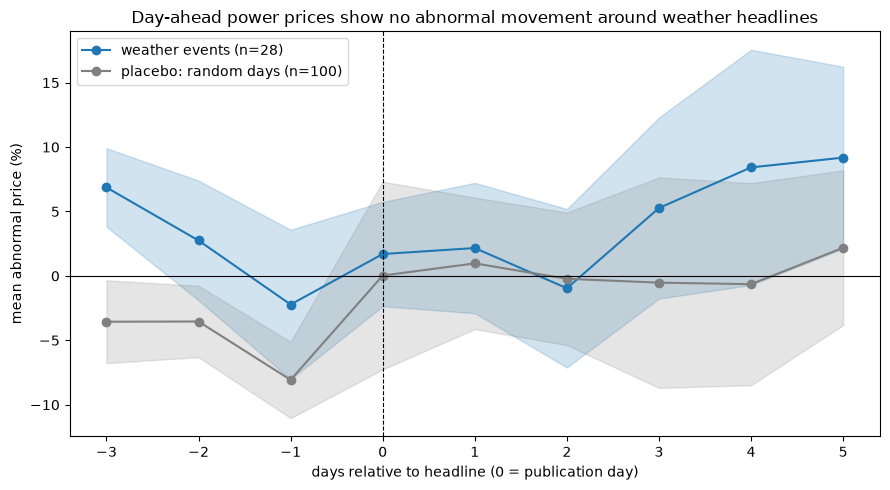

In [151]:
#Final figure for the README
import matplotlib.pyplot as plt
import os
os.makedirs('../reports', exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
for df, color, label in [(curve, 'tab:blue', 'weather events (n=28)'),
                         (placebo_curve, 'gray', 'placebo: random days (n=100)')]:
    se = df['std'] / np.sqrt(df['count'])
    ax.plot(df.index, df['mean'], color=color, marker='o', label=label)
    ax.fill_between(df.index, df['mean'] - se, df['mean'] + se, color=color, alpha=0.2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('days relative to headline (0 = publication day)')
ax.set_ylabel('mean abnormal price (%)')
ax.set_title('Day-ahead power prices show no abnormal movement around weather headlines')
ax.legend()
fig.tight_layout()
fig.savefig('../reports/event_study.png', dpi=150)
plt.show()